# 데이터 전처리

모델 학습 전 데이터를 정제합니다. 결과는 `data/nhanes_preprocessed.csv` 로 저장됩니다.

**실행 순서:** 이 노트북 먼저 실행 → `train.ipynb` 실행

## 1. 로드 및 기본 확인

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

RAW_PATH  = "../data/nhanes_fatty_liver.csv"
SAVE_PATH = "../data/nhanes_preprocessed.csv"

df = pd.read_csv(RAW_PATH)
print(f"원본 shape: {df.shape}")
df.head()

원본 shape: (13436, 21)


,나이,성별,키,몸무게,BMI,허리둘레,음주여부,1회음주량,주당음주빈도,월폭음빈도,...,주당운동횟수,흡연여부,현재흡연여부,당뇨진단여부,고혈압진단여부,수면장애여부,평균수면시간,식습관자가평가,지방간단계,지방간단계명
0,66.0,여성,158.3,79.5,31.7,101.8,음주함,1.0,0.25,0.75,...,0,흡연경험있음,안함,없음,있음,없음,8.0,보통,0,정상
1,18.0,남성,175.7,66.3,21.5,79.3,음주안함,0.0,0.00,0.00,...,2,흡연경험없음,안함,없음,없음,없음,10.5,좋음,0,정상
2,66.0,여성,150.2,53.5,23.7,88.2,음주안함,0.0,0.00,0.00,...,0,흡연경험없음,안함,경계성,있음,없음,8.0,매우좋음,1,경미
3,75.0,여성,151.1,88.8,38.9,113.0,음주함,2.0,0.60,0.75,...,0,흡연경험있음,매일,없음,있음,없음,7.0,보통,2,중등도
4,56.0,남성,170.6,62.1,21.3,86.6,음주함,1.0,1.00,0.75,...,2,흡연경험없음,안함,없음,없음,있음,7.0,좋음,0,정상


## 2. 결측값 처리

In [2]:
print("=== 결측값 현황 ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"결측 수": missing, "비율(%)": missing_pct})
print(missing_df[missing_df["결측 수"] > 0])
print(f"\n총 결측 행: {df.isnull().any(axis=1).sum()}건")

=== 결측값 현황 ===
Empty DataFrame
Columns: [결측 수, 비율(%)]
Index: []

총 결측 행: 0건


In [3]:
NUMERIC_COLS  = ["나이", "키", "몸무게", "BMI", "허리둘레",
                 "1회음주량", "주당음주빈도", "월폭음빈도", "주당운동횟수", "평균수면시간"]
CATEGORY_COLS = ["성별", "음주여부", "운동여부", "흡연여부", "현재흡연여부",
                 "당뇨진단여부", "고혈압진단여부", "수면장애여부", "식습관자가평가"]

for col in NUMERIC_COLS:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"{col}: 중앙값({median_val}) 대체")

for col in CATEGORY_COLS:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"{col}: 최빈값({mode_val}) 대체")

print(f"\n처리 후 결측값: {df.isnull().sum().sum()}건")


처리 후 결측값: 0건


## 3. 이상값 처리

In [4]:
RANGE_RULES = {
    "나이":         (12, 80),
    "키":           (130, 220),
    "몸무게":       (30, 200),
    "허리둘레":     (50, 180),
    "1회음주량":    (0, 30),
    "주당음주빈도": (0, 7),
    "월폭음빈도":   (0, 30),
    "주당운동횟수": (0, 7),
    "평균수면시간": (2, 14),
}

print("=== 범위 외 이상값 현황 ===")
for col, (lo, hi) in RANGE_RULES.items():
    out = ((df[col] < lo) | (df[col] > hi)).sum()
    if out > 0:
        print(f"{col} [{lo}~{hi}]: {out}건")

# 키/몸무게 먼저 클리핑
for col, (lo, hi) in RANGE_RULES.items():
    df[col] = df[col].clip(lower=lo, upper=hi)

# BMI는 키/몸무게 클리핑 후 재계산 (파생 변수라 독립 클리핑 불가)
df["BMI"] = (df["몸무게"] / (df["키"] / 100) ** 2).round(1)
print(f"BMI 재계산 완료: min={df['BMI'].min():.1f}, max={df['BMI'].max():.1f}")
print("클리핑 완료")


=== 범위 외 이상값 현황 ===
몸무게 [30~200]: 8건
허리둘레 [50~180]: 1건
BMI 재계산 완료: min=14.6, max=77.8
클리핑 완료


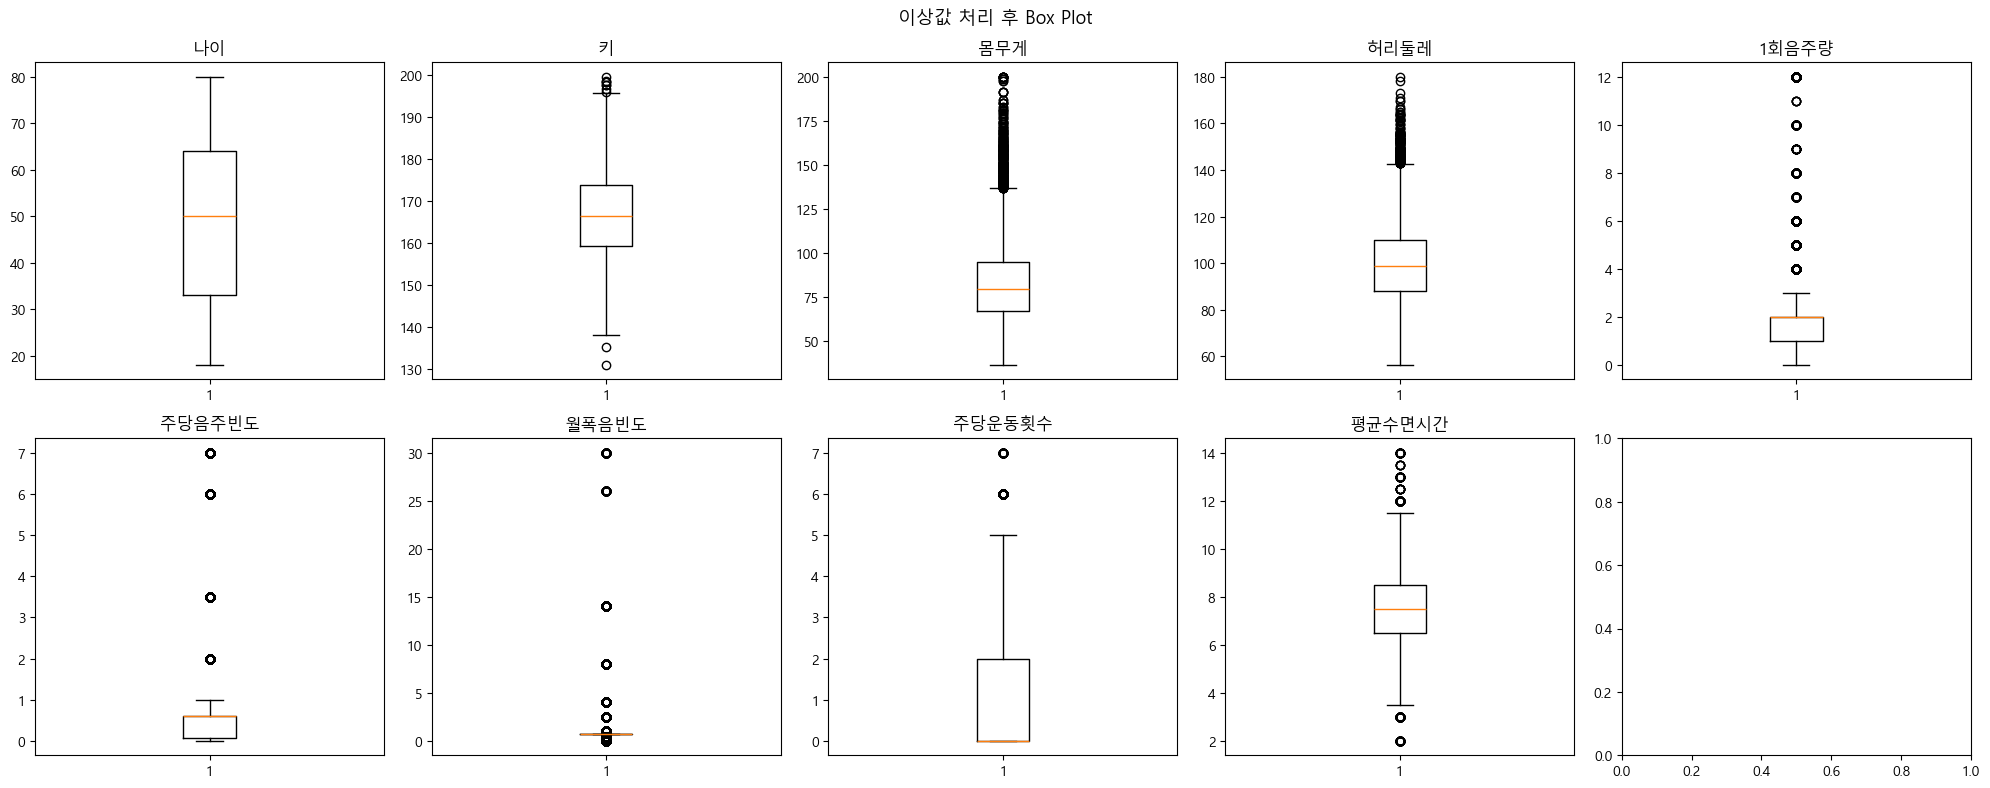

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, col in enumerate(RANGE_RULES.keys()):
    axes[i // 5][i % 5].boxplot(df[col].dropna())
    axes[i // 5][i % 5].set_title(col)
plt.suptitle("이상값 처리 후 Box Plot", fontsize=13)
plt.tight_layout()
plt.show()

## 4. 음주량 단위 확인

> **중요**: `1회음주량` 단위는 **표준음주(잔)** 기준입니다.
> 프론트엔드에서 주류 종류별 입력을 받으면 백엔드가 아래 기준으로 변환 후 저장합니다.
>
> | 주종 | 1잔 기준 | 표준음주 환산 |
> |------|---------|-------------|
> | 맥주 | 355ml | 1.0잔 |
> | 소주 | 50ml | 0.8잔 |
> | 막걸리 | 200ml | 1.2잔 |
> | 와인 | 150ml | 1.5잔 |
> | 양주 | 45ml | 1.0잔 |

1회음주량 통계 (음주자만):
count    14315.000000
mean         2.325603
std          1.604263
min          1.000000
25%          2.000000
50%          2.000000
75%          2.000000
max         11.000000
Name: 1회음주량, dtype: float64


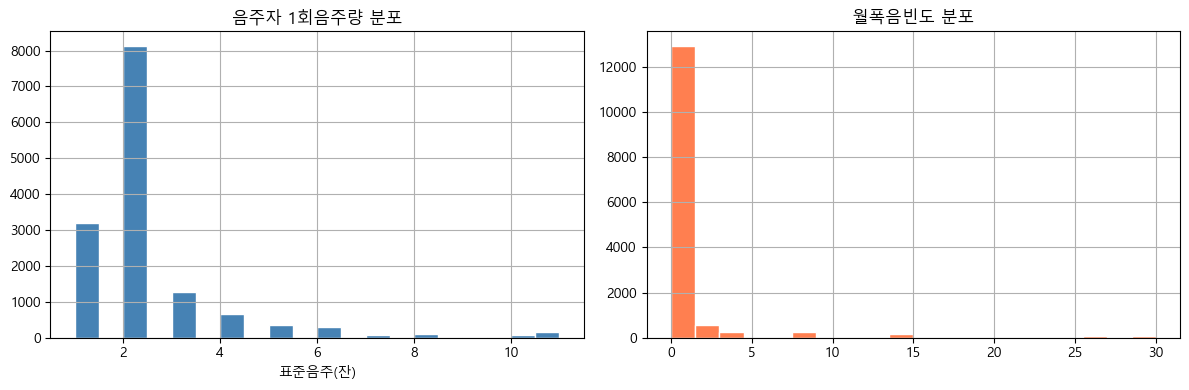

In [6]:
print("1회음주량 통계 (음주자만):")
print(df[df["음주여부"] == "음주함"]["1회음주량"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df[df["음주여부"] == "음주함"]["1회음주량"].hist(ax=axes[0], bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("음주자 1회음주량 분포")
axes[0].set_xlabel("표준음주(잔)")
df[df["음주여부"] == "음주함"]["월폭음빈도"].hist(ax=axes[1], bins=20, color="coral", edgecolor="white")
axes[1].set_title("월폭음빈도 분포")
plt.tight_layout()
plt.show()

## 5. 클래스 불균형 확인 및 처리 (SMOTE)

=== 클래스 분포 ===
  정상 (0): 4894건 (36.4%)
  경도 (1): 1639건 (12.2%)
  중등도 (2): 2314건 (17.2%)
  중증 (3): 4589건 (34.2%)


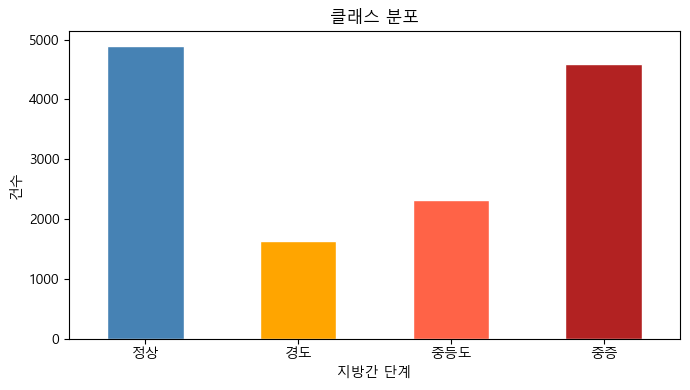

In [6]:
TARGET = "지방간단계"
label_map = {0: "정상", 1: "경도", 2: "중등도", 3: "중증"}

print("=== 클래스 분포 ===")
dist = df[TARGET].value_counts().sort_index()
for k, v in dist.items():
    print(f"  {label_map[k]} ({k}): {v}건 ({v/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(7, 4))
dist.rename(label_map).plot(kind="bar", ax=ax, color=["steelblue", "orange", "tomato", "firebrick"], edgecolor="white")
ax.set_title("클래스 분포")
ax.set_xlabel("지방간 단계")
ax.set_ylabel("건수")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

In [7]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer

NUMERIC_FEATURES = ["나이", "키", "몸무게", "BMI", "허리둘레",
                    "1회음주량", "주당음주빈도", "월폭음빈도", "주당운동횟수", "평균수면시간"]
BINARY_FEATURES  = ["성별", "음주여부", "운동여부", "흡연여부", "현재흡연여부",
                    "당뇨진단여부", "고혈압진단여부", "수면장애여부"]
ORDINAL_FEATURES = ["식습관자가평가"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", NUMERIC_FEATURES),
        ("bin", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), BINARY_FEATURES),
        ("ord", OrdinalEncoder(categories=[["나쁨", "보통", "좋음"]], handle_unknown="use_encoded_value", unknown_value=-1), ORDINAL_FEATURES),
    ],
    remainder="drop"
)

X = df.drop(columns=[TARGET, "지방간단계명"])
y = df[TARGET]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train_enc = preprocessor.fit_transform(X_train_raw)
X_test_enc  = preprocessor.transform(X_test_raw)

print(f"SMOTE 전 train 분포: {dict(pd.Series(y_train).value_counts().sort_index())}")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_enc, y_train)
print(f"SMOTE 후 train 분포: {dict(pd.Series(y_train_resampled).value_counts().sort_index())}")
print(f"Train: {X_train_resampled.shape}, Test: {X_test_enc.shape}")

SMOTE 전 train 분포: {0: np.int64(3915), 1: np.int64(1311), 2: np.int64(1851), 3: np.int64(3671)}
SMOTE 후 train 분포: {0: np.int64(3915), 1: np.int64(3915), 2: np.int64(3915), 3: np.int64(3915)}
Train: (15660, 19), Test: (2688, 19)


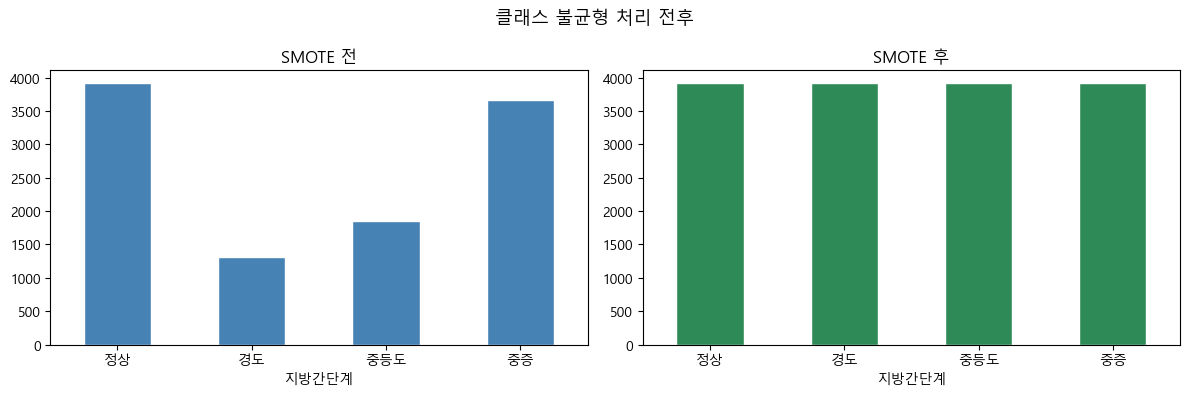

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.Series(y_train).value_counts().sort_index().rename(label_map).plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("SMOTE 전")
axes[0].tick_params(axis="x", rotation=0)

pd.Series(y_train_resampled).value_counts().sort_index().rename(label_map).plot(
    kind="bar", ax=axes[1], color="seagreen", edgecolor="white")
axes[1].set_title("SMOTE 후")
axes[1].tick_params(axis="x", rotation=0)

plt.suptitle("클래스 불균형 처리 전후", fontsize=13)
plt.tight_layout()
plt.show()

## 6. 전처리 결과 저장

In [9]:
import os
import joblib

df_clean = pd.concat([X, y, df["지방간단계명"]], axis=1)
df_clean.to_csv(SAVE_PATH, index=False, encoding="utf-8-sig")
print(f"정제 데이터 저장: {SAVE_PATH}  shape={df_clean.shape}")

PREP_DIR = "../ai_worker/models"
os.makedirs(PREP_DIR, exist_ok=True)
joblib.dump(preprocessor, os.path.join(PREP_DIR, "preprocessor.pkl"))
print("전처리기 저장: ai_worker/models/preprocessor.pkl")

print(f"\n=== 전처리 완료 ===")
print(f"원본: {len(df)}건  →  정제: {len(df_clean)}건")
print("다음 단계: train.ipynb 에서 nhanes_preprocessed.csv 사용")

정제 데이터 저장: ../data/nhanes_preprocessed.csv  shape=(13436, 21)
전처리기 저장: ai_worker/models/preprocessor.pkl

=== 전처리 완료 ===
원본: 13436건  →  정제: 13436건
다음 단계: train.ipynb 에서 nhanes_preprocessed.csv 사용


In [1]:
import pandas as pd

# 4개 파일 합치기
files = [
    "../data/hn21_all.sas7bdat",
    "../data/hn22_all.sas7bdat",
    "../data/hn23_all.sas7bdat",
    "../data/hn24_all.sas7bdat",
]

dfs = [pd.read_sas(f, encoding="latin1") for f in files]
df = pd.concat(dfs, ignore_index=True)
print(f"합친 shape: {df.shape}")

# 필요 컬럼 확인
cols = df.columns.tolist()
keywords = ["age", "sex", "HE_ht", "HE_wt", "HE_BMI", "HE_wc",
            "BD", "PA_", "sm_", "BP_sleep", "DI1", "HE_HP", "N_SLEEP"]

for kw in keywords:
    matched = [c for c in cols if kw.lower() in c.lower()]
    print(f"{kw}: {matched}")

합친 shape: (27281, 1185)
age: ['age', 'age_month']
sex: ['sex']
HE_ht: ['HE_ht', 'HE_HTG']
HE_wt: ['HE_wt', 'HE_wt_pct']
HE_BMI: ['HE_BMI', 'HE_BMI_pct']
HE_wc: ['HE_wc']
BD: ['BD1', 'BD2', 'BD1_11', 'BD2_1', 'BD2_14', 'BD2_31', 'BD2_32', 'BD7_4', 'BD7_5', 'BD7_61', 'BD7_62', 'BD7_63', 'BD7_64', 'BD7_65', 'BD7_66', 'BD7_67', 'BD9_1', 'BD9_2']
PA_: ['pa_aerobic']
sm_: ['sm_presnt']
BP_sleep: []
DI1: ['DI1_dg', 'DI1_ag', 'DI1_pr', 'DI1_pt', 'DI1_2']
HE_HP: ['HE_HPdr', 'HE_HPfh1', 'HE_HPfh2', 'HE_HPfh3', 'HE_HP']
N_SLEEP: []


In [15]:
# 수면, 식습관 관련 컬럼 찾기
sleep_cols = [c for c in cols if "sleep" in c.lower() or "SL" in c or "수면" in c.lower()]
diet_cols = [c for c in cols if "diet" in c.lower() or "NQ" in c or "N_" in c]
print("수면:", sleep_cols)
print("식습관:", diet_cols[:30])

# 음주 관련 값 확인
print("\nBD1_11 유니크값:", df["BD1_11"].value_counts())
print("\nBD2_1 유니크값:", df["BD2_1"].value_counts())
print("\nBD2_31 유니크값:", df["BD2_31"].value_counts())

# 운동
print("\npa_aerobic 유니크값:", df["pa_aerobic"].value_counts())

# 흡연
print("\nsm_presnt 유니크값:", df["sm_presnt"].value_counts())


수면: []
식습관: ['O_BR_N_U', 'O_BR_N_L', 'T_NQ_OCP', 'T_Q_VN_1', 'T_Q_VN_2', 'L_LN_FQ', 'L_DN_FQ', 'L_LN_TO', 'L_LN_WHO', 'L_DN_TO', 'L_DN_WHO', 'Y_WN_ST', 'N_DIET', 'N_DIET_WHY', 'N_DT_DS', 'N_DT_ETC', 'N_DUSUAL', 'N_WAT_C', 'N_PRG', 'N_BFD_Y', 'N_DAY', 'N_INTK', 'N_EN', 'N_WATER', 'N_PROT', 'N_FAT', 'N_SFA', 'N_MUFA', 'N_PUFA', 'N_N3']

BD1_11 유니크값: BD1_11
8.0    6267
4.0    4678
2.0    4433
1.0    4405
5.0    3010
3.0    2378
6.0    1270
9.0     460
Name: count, dtype: int64

BD2_1 유니크값: BD2_1
8.0    10672
1.0     5918
2.0     3183
4.0     2694
5.0     2137
3.0     1837
9.0      460
Name: count, dtype: int64

BD2_31 유니크값: BD2_31
8.0    10672
1.0     6659
2.0     3061
4.0     2934
3.0     2283
5.0      827
9.0      465
Name: count, dtype: int64

pa_aerobic 유니크값: pa_aerobic
0.0    11781
1.0     9267
Name: count, dtype: int64

sm_presnt 유니크값: sm_presnt
0.0    19097
1.0     3364
Name: count, dtype: int64


In [16]:
# 수면시간, 흡연 관련 더 찾기
more_sleep = [c for c in cols if any(x in c.upper() for x in ["SL", "SLEEP", "BD9"])]
more_smoke = [c for c in cols if "sm_" in c.lower()]
exercise = [c for c in cols if "pa_" in c.lower()]
print("수면 관련:", more_sleep)
print("흡연 관련:", more_smoke)
print("운동 관련:", exercise)

# 주당 운동 횟수 관련
print("\nBD9_1 유니크값:", df["BD9_1"].value_counts())
print("\nBD9_2 유니크값:", df["BD9_2"].value_counts())


수면 관련: ['BD9_1', 'BD9_2']
흡연 관련: ['sm_presnt']
운동 관련: ['pa_aerobic']

BD9_1 유니크값: BD9_1
2.0    3112
1.0    1812
8.0    1747
9.0      57
Name: count, dtype: int64

BD9_2 유니크값: BD9_2
8.0    2933
1.0    2499
4.0     592
2.0     509
3.0     147
9.0      48
Name: count, dtype: int64


In [ ]:
print("T_NQ_OCP:", df["T_NQ_OCP"].value_counts().head(10))
print("T_NQ_OCP 통계:", df["T_NQ_OCP"].describe())
print("\nN_DUSUAL:", df["N_DUSUAL"].value_counts())

N_DIET
2.0    18273
1.0     7078
9.0        7
Name: count, dtype: int64
